<a href="https://colab.research.google.com/github/elizrust01/wizard-of-oz-nlp/blob/main/Wizard_of_Oz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
from bs4 import BeautifulSoup
import re
from textblob import TextBlob
from collections import Counter
import matplotlib.pyplot as plt

In [98]:
with open("The Wonderful Wizard of Oz.html") as fp:
    soup = BeautifulSoup(fp, 'html.parser')

text = soup.get_text()

start = text.find('Chapter I')
end_phrase = "“And here is Toto, too. And oh, Aunt Em! I’m so glad to be at home again!”"
end_pos = text.find(end_phrase) + len(end_phrase)
book = text[start:end_pos]

print(f"book length: {len(book)}")
print(book[-200:])

book length: 0



In [99]:
idx = text.find("cyclone")
print(idx)
print(text[idx-100:idx+100])

3870
r corner. There was no garret at all,
and no cellar—except a small hole dug in the ground, called a cyclone
cellar, where the family could go in case one of those great whirlwinds arose,
mighty enough


In [100]:
start = text.find('Chapter I')
print(start)
print(text.find("Aunt Em"))

1038
3371


In [101]:
start = text.find('Chapter I')
end_phrase = "Aunt Em"
end_pos = text.rfind("Aunt Em") + len("Aunt Em")
book = text[start:end_pos]

print(f"book length: {len(book)}")
print(book[:200])
print("---")
print(book[-200:])

book length: 208697
Chapter I. The Cyclone


 Chapter II. The Council with the Munchkins


 Chapter III. How Dorothy Saved the Scarecrow


 Chapter IV. The Road Through the Forest


 Chapter V. The Rescue of the Tin Wood
---
d, folding the little girl in her arms
and covering her face with kisses. “Where in the world did you come
from?”


“From the Land of Oz,” said Dorothy gravely. “And here is
Toto, too. And oh, Aunt Em


In [102]:
chapters = re.split(r'(Chapter [IVXLC]+)', book)
chapters = [c.strip() for c in chapters if c.strip()]

chapters_dict = {}
for i in range(0, len(chapters)-1, 2):
    label = chapters[i].strip()
    content = chapters[i+1].strip()
    chapters_dict[label] = content

for chapter, content in chapters_dict.items():
    print(f"{chapter}: {len(content)} characters")

Chapter I: 5990 characters
Chapter II: 10660 characters
Chapter III: 10345 characters
Chapter IV: 7508 characters
Chapter V: 10435 characters
Chapter VI: 7865 characters
Chapter VII: 9472 characters
Chapter VIII: 10115 characters
Chapter IX: 7311 characters
Chapter X: 10170 characters
Chapter XI: 18819 characters
Chapter XII: 19080 characters
Chapter XIII: 6344 characters
Chapter XIV: 9962 characters
Chapter XV: 14495 characters
Chapter XVI: 4928 characters
Chapter XVII: 5922 characters
Chapter XVIII: 6219 characters
Chapter XIX: 5380 characters
Chapter XX: 8214 characters
Chapter XXI: 4764 characters
Chapter XXII: 5079 characters
Chapter XXIII: 6673 characters
Chapter XXIV: 358 characters


In [103]:
print(chapters_dict['Chapter XXIV'])

Home Again

Aunt Em had just come out of the house to water the cabbages when she looked up
and saw Dorothy running toward her.


“My darling child!” she cried, folding the little girl in her arms
and covering her face with kisses. “Where in the world did you come
from?”


“From the Land of Oz,” said Dorothy gravely. “And here is
Toto, too. And oh, Aunt Em


In [104]:
for name in ['Dorothy', 'Witch', 'Scarecrow', 'Woodman', 'Wizard', 'Lion']:
    count = book.lower().count(name.lower())
    print(f"{name}: {count}")

Dorothy: 369
Witch: 142
Scarecrow: 227
Woodman: 183
Wizard: 42
Lion: 183


In [105]:
for name in ['Toto', 'Glinda', 'Aunt Em', 'Uncle Henry', 'Cowardly', 'Nick']:
    count = book.lower().count(name.lower())
    print(f"{name}: {count}")

Toto: 93
Glinda: 19
Aunt Em: 23
Uncle Henry: 13
Cowardly: 24
Nick: 2


In [106]:
for name in ['Hunk', 'Hickory', 'Zeke', 'Marvel', 'Gulch', 'Gale']:
    count = book.lower().count(name.lower())
    print(f"{name}: {count}")

Hunk: 0
Hickory: 0
Zeke: 0
Marvel: 2
Gulch: 0
Gale: 0


In [107]:
idx = book.lower().find("marvel")
print(book[idx-100:idx+100])

h the
ages, for every healthy youngster has a wholesome and instinctive love for
stories fantastic, marvelous and manifestly unreal. The winged fairies of Grimm
and Andersen have brought more happines


In [108]:
characters = {
    "Dorothy": ["Dorothy"],
    "Scarecrow": ["Scarecrow"],
    "Woodman": ["Woodman", "Tinman"],
    "Lion": ["Lion"],
    "Witch": ["Witch"],
    "Wizard": ["Wizard"],
    "Toto": ["Toto"],
    "Glinda": ["Glinda"],
    "Aunt Em": ["Aunt Em"],
}

In [109]:
def count_mentions_per_chapter(chapters_dict, characters):
    chapter_counts = []
    for chapter, text in chapters_dict.items():
        counts = {char: 0 for char in characters.keys()}
        for name, aliases in characters.items():
            counts[name] = sum(text.count(alias) for alias in aliases)
        chapter_counts.append(counts)
    return chapter_counts

results = count_mentions_per_chapter(chapters_dict, characters)
print(results[0])

{'Dorothy': 17, 'Scarecrow': 0, 'Woodman': 0, 'Lion': 0, 'Witch': 0, 'Wizard': 0, 'Toto': 10, 'Glinda': 0, 'Aunt Em': 7}


In [110]:
chapter_labels = list(chapters_dict.keys())
dorothy_counts = [r['Dorothy'] for r in results]
toto_counts = [r['Toto'] for r in results]
scarecrow_counts = [r['Scarecrow'] for r in results]
witch_counts = [r['Witch'] for r in results]
wizard_counts = [r['Wizard'] for r in results]
lion_counts = [r['Lion'] for r in results]
woodman_counts = [r['Woodman'] for r in results]
aunt_em_counts = [r['Aunt Em'] for r in results]
glinda_counts = [r['Glinda'] for r in results]
print(dorothy_counts)
print(toto_counts)
print(scarecrow_counts)
print(witch_counts)
print(wizard_counts)
print(lion_counts)
print(woodman_counts)
print(aunt_em_counts)
print(glinda_counts)

[17, 30, 25, 8, 13, 15, 14, 19, 5, 18, 33, 38, 13, 16, 18, 3, 10, 15, 8, 22, 4, 7, 13, 2]
[10, 3, 14, 3, 4, 9, 4, 5, 5, 6, 3, 8, 1, 2, 2, 0, 2, 0, 2, 3, 2, 2, 2, 1]
[0, 0, 13, 16, 18, 9, 16, 20, 10, 8, 14, 14, 8, 6, 14, 10, 3, 11, 8, 10, 2, 7, 7, 0]
[0, 19, 4, 0, 5, 1, 0, 1, 0, 0, 19, 47, 3, 3, 11, 0, 0, 3, 0, 0, 0, 1, 8, 0]
[0, 3, 0, 0, 0, 0, 1, 0, 0, 4, 7, 0, 0, 0, 11, 2, 6, 1, 2, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 25, 25, 16, 9, 11, 13, 17, 7, 3, 7, 9, 1, 2, 5, 5, 16, 3, 5, 0]
[0, 0, 0, 0, 16, 14, 14, 17, 16, 4, 15, 18, 14, 5, 8, 11, 2, 7, 7, 6, 1, 1, 5, 0]
[7, 2, 0, 0, 1, 0, 0, 0, 0, 0, 4, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 3, 2]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 2, 11, 0]


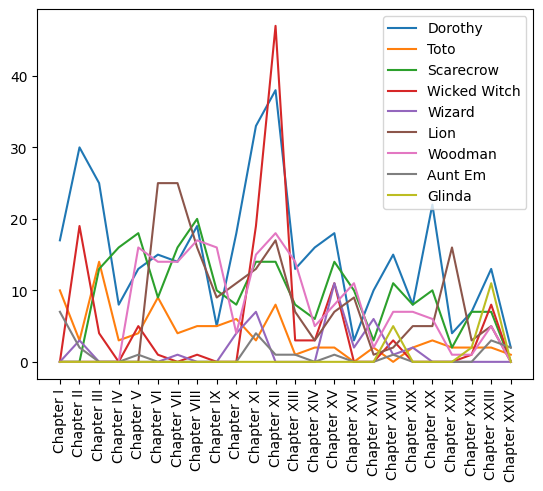

In [111]:
plt.plot(dorothy_counts, label='Dorothy')
plt.plot(toto_counts, label='Toto')
plt.plot(scarecrow_counts, label='Scarecrow')
plt.plot(witch_counts, label='Wicked Witch')
plt.plot(wizard_counts, label='Wizard')
plt.plot(lion_counts, label='Lion')
plt.plot(woodman_counts, label='Woodman')
plt.plot(aunt_em_counts, label='Aunt Em')
plt.plot(glinda_counts, label='Glinda')
plt.legend()
plt.savefig('character_mentions.png', bbox_inches='tight', dpi=150)
plt.xticks(range(len(chapter_labels)), chapter_labels, rotation=90)
plt.savefig('oz_character_mentions.png', bbox_inches='tight', dpi=150)
plt.show()

In [112]:
scores = []
for i, chapter in enumerate(chapters_dict.values()):
    polarity = TextBlob(chapter).sentiment.polarity
    scores.append(polarity)

print(scores)

[0.02453854583571565, 0.10845921727137196, 0.11633376299106639, 0.11020383963862224, 0.1489759550929764, 0.04428169897735116, 0.11000770416024658, 0.08450779727095518, 0.07904012795594426, 0.1605697957013747, 0.10519528249528251, 0.03401692772875979, 0.1854699482789371, 0.2308131055452484, 0.06845016191818518, 0.28548451548451553, 0.18247549019607837, 0.16773418348719546, 0.1902608728480822, 0.042501321927691765, 0.17260121983959198, 0.16145600627082102, 0.3086515228270547, -0.1875]


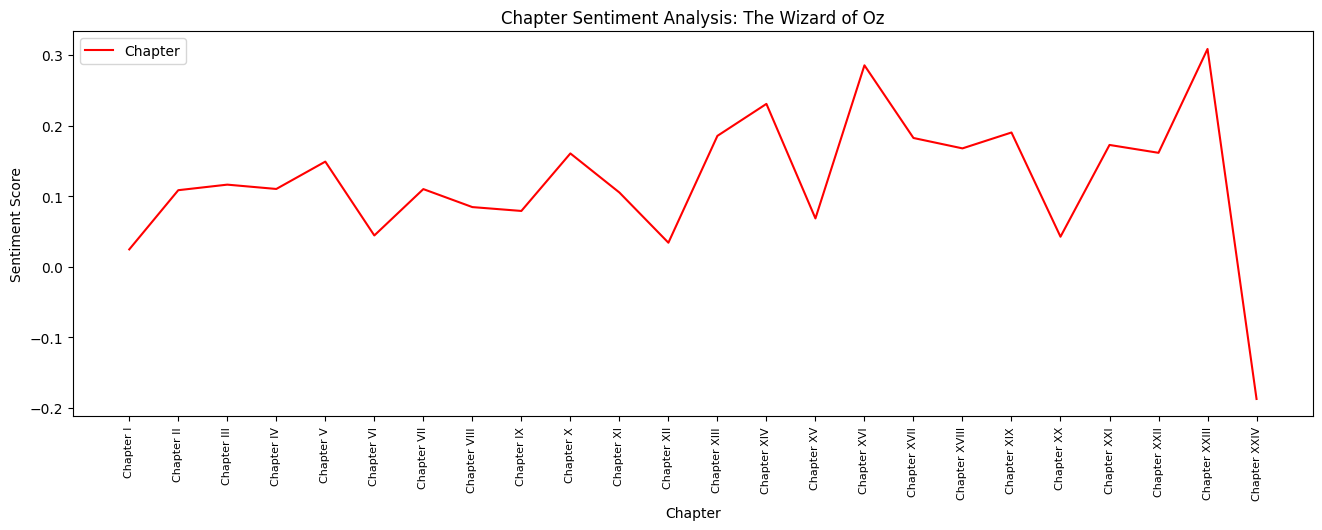

In [113]:
plt.figure(figsize=(16,5))
plt.plot(range(len(chapter_labels)), scores, label='Chapter', color='red')
plt.title("Chapter Sentiment Analysis: The Wizard of Oz")
plt.xlabel("Chapter")
plt.ylabel("Sentiment Score")
plt.xticks(range(len(chapter_labels)), chapter_labels, rotation=90, fontsize=8)
plt.legend()
plt.savefig('oz_sentiment_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

In [114]:

def get_context_words(text, name, window=10):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    context = []
    for i, word in enumerate(words):
        if word == name.lower():
            context.extend(words[i-window:i+window])
    return context

In [115]:
dorothy_context = get_context_words(book, "Dorothy")
witch_context = get_context_words(book, "Witch")

print(len(dorothy_context))
print(len(witch_context))

7380
2580


In [116]:
!pip install nltk
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [117]:
from collections import Counter

In [118]:
dorothy_custom_stops = {'dorothy'}
witch_custom_stops = {'witch'}
wizard_custom_stops = {'wizard'}

In [119]:
dorothy_custom_stops = {'dorothy'}
witch_custom_stops = {'witch', 'wicked'}
wizard_custom_stops = {'wizard'}

generic_stops = {'shall', 'cannot', 'went', 'said', 'asked', 'back', 'upon', 'could', 'would', 'chapter', 'answered', 'must', 'made', 'came', 'away', 'looked', 'thought', 'good'}

dorothy_filtered = [w for w in dorothy_context if w not in stop_words and w not in dorothy_custom_stops and w not in generic_stops and len(w) > 3]
witch_filtered = [w for w in witch_context if w not in stop_words and w not in witch_custom_stops and w not in generic_stops and len(w) > 3]
wizard_filtered = [w for w in wizard_context if w not in stop_words and w not in wizard_custom_stops and w not in generic_stops and len(w) > 3]

dorothy_counts = Counter(dorothy_filtered)
witch_counts = Counter(witch_filtered)
wizard_counts = Counter(wizard_filtered)

print("DOROTHY:")
print(dorothy_counts.most_common(20))
print("\nWITCH:")
print(witch_counts.most_common(20))
print("\nWIZARD:")
print(wizard_counts.most_common(20))

DOROTHY:
[('witch', 39), ('toto', 32), ('lion', 31), ('scarecrow', 30), ('little', 29), ('green', 25), ('woodman', 20), ('city', 17), ('great', 16), ('kansas', 16), ('found', 16), ('walked', 15), ('girl', 15), ('never', 14), ('first', 12), ('eyes', 12), ('cried', 12), ('help', 12), ('know', 12), ('head', 12)]

WITCH:
[('dorothy', 32), ('east', 13), ('west', 13), ('shoes', 10), ('kill', 10), ('lion', 10), ('silver', 8), ('killed', 7), ('north', 7), ('little', 6), ('great', 6), ('winkies', 6), ('castle', 6), ('country', 5), ('glinda', 5), ('land', 5), ('powerful', 5), ('girl', 5), ('voice', 5), ('know', 5)]

WIZARD:
[('great', 14), ('dorothy', 7), ('wonderful', 4), ('well', 4), ('told', 3), ('city', 3), ('like', 3), ('palace', 3), ('people', 3), ('many', 3), ('lion', 3), ('lived', 2), ('witch', 2), ('girl', 2), ('whether', 2), ('emerald', 2), ('soon', 2), ('send', 2), ('take', 2), ('hard', 2)]


In [120]:
generic_stops = {'shall','cannot','went','said', 'asked', 'back', 'upon', 'could', 'would', 'chapter', 'answered', 'must', 'made', 'came', 'away', 'looked', 'thought', 'good'}
witch_custom_stops = {'witch', 'wicked'}

dorothy_filtered = [w for w in dorothy_context if w not in stop_words and w not in dorothy_custom_stops and w not in generic_stops and len(w) > 3]
witch_filtered = [w for w in witch_context if w not in stop_words and w not in witch_custom_stops and w not in generic_stops and len(w) > 3]
wizard_filtered = [w for w in wizard_context if w not in stop_words and w not in wizard_custom_stops and w not in generic_stops and len(w) > 3]

dorothy_counts = Counter(dorothy_filtered)
witch_counts = Counter(witch_filtered)
wizard_counts = Counter(wizard_filtered)

print("DOROTHY:")
print(dorothy_counts.most_common(20))
print("\nWITCH:")
print(witch_counts.most_common(20))
print("\nWIZARD:")
print(wizard_counts.most_common(20))

DOROTHY:
[('witch', 39), ('toto', 32), ('lion', 31), ('scarecrow', 30), ('little', 29), ('green', 25), ('woodman', 20), ('city', 17), ('great', 16), ('kansas', 16), ('found', 16), ('walked', 15), ('girl', 15), ('never', 14), ('first', 12), ('eyes', 12), ('cried', 12), ('help', 12), ('know', 12), ('head', 12)]

WITCH:
[('dorothy', 32), ('east', 13), ('west', 13), ('shoes', 10), ('kill', 10), ('lion', 10), ('silver', 8), ('killed', 7), ('north', 7), ('little', 6), ('great', 6), ('winkies', 6), ('castle', 6), ('country', 5), ('glinda', 5), ('land', 5), ('powerful', 5), ('girl', 5), ('voice', 5), ('know', 5)]

WIZARD:
[('great', 14), ('dorothy', 7), ('wonderful', 4), ('well', 4), ('told', 3), ('city', 3), ('like', 3), ('palace', 3), ('people', 3), ('many', 3), ('lion', 3), ('lived', 2), ('witch', 2), ('girl', 2), ('whether', 2), ('emerald', 2), ('soon', 2), ('send', 2), ('take', 2), ('hard', 2)]


In [121]:
dorothy_words, dorothy_top_counts = zip(*dorothy_counts.most_common(15))
witch_words, witch_top_counts = zip(*witch_counts.most_common(15))
wizard_words, wizard_top_counts = zip(*wizard_counts.most_common(15))

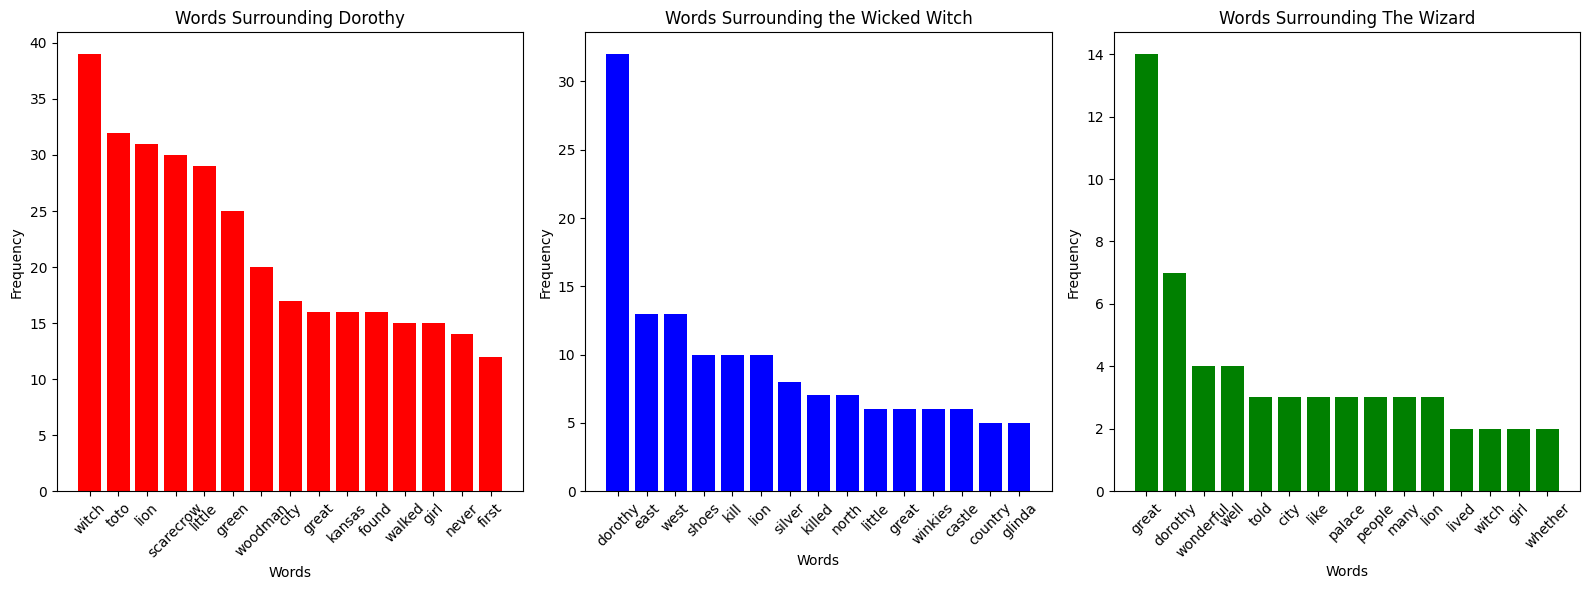

In [122]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))
ax1.bar(dorothy_words, dorothy_top_counts, color='red')
ax1.set_title("Words Surrounding Dorothy")
ax1.set_xlabel("Words")
ax1.set_ylabel("Frequency")
ax1.tick_params(axis='x', rotation=45)
ax2.bar(witch_words, witch_top_counts, color='blue')
ax2.set_title("Words Surrounding the Wicked Witch")
ax2.set_xlabel("Words")
ax2.set_ylabel("Frequency")
ax2.tick_params(axis='x', rotation=45)
ax3.bar(wizard_words, wizard_top_counts, color='green')
ax3.set_title("Words Surrounding The Wizard")
ax3.set_xlabel("Words")
ax3.set_ylabel("Frequency")
ax3.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('words_surrounding_dorothy_witch_wizard', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')